# K-Nearest Neighbors (KNN)

## What Is KNN?

KNN is a **non-parametric, lazy learning** algorithm. These two terms are worth unpacking:

- **Non-parametric** means the model does not learn a fixed equation like $\mathbf{w}^T\mathbf{x} + b$. There are no parameters to fit. The data itself is the model.
- **Lazy learning** means there is no training phase at all. The algorithm simply stores the entire training dataset and defers all computation to prediction time.

KNN makes predictions purely by looking at how close a new point is to points it has already seen.

## The Core Idea

To classify a new point, KNN follows three steps:

1. Choose a number $k$
2. Find the $k$ closest training points to the new point
3. Take a **majority vote** of their labels — whichever class appears most among the $k$ neighbors wins

That is the entire algorithm. No matrix inversion, no gradient descent, no parameters to update.

For **regression** (predicting a continuous value), the same logic applies — instead of a majority vote, you take the **average** of the $k$ neighbors' output values.

## Why Do We Need KNN?

Logistic regression finds a decision boundary defined by:

$$\mathbf{w}^T\mathbf{x} + b = 0$$

This is always a straight line (or flat hyperplane). It fundamentally cannot separate classes that form circles, spirals, or complex clusters.

KNN makes no assumption about the shape of the boundary. Because it bases decisions purely on local neighborhood, it adapts naturally to any shape of decision boundary — linear or not. Wherever the training data has a particular label, predictions in that region will reflect it.

## The Distance Metric

The most common way to measure closeness is **Euclidean distance**. For a test point $\mathbf{x}$ and a training point $\mathbf{x}_i$, both with $n$ features:

$$d(\mathbf{x}, \mathbf{x}_i) = \sqrt{\sum_{j=1}^{n}(x_j - x_{ij})^2}$$

In 2D, this simplifies to the familiar formula:

$$d = \sqrt{(x_1 - x_{i1})^2 + (x_2 - x_{i2})^2}$$

Other distance metrics can be used depending on the problem:

- **Manhattan distance** — sum of absolute differences along each axis; useful when movement is grid-like
- **Minkowski distance** — a generalization that includes both Euclidean ($p=2$) and Manhattan ($p=1$) as special cases
- **Cosine distance** — measures the angle between vectors; useful for text and high-dimensional sparse data

The choice of distance metric can significantly affect performance.

## Choosing $k$

The value of $k$ is the most important hyperparameter in KNN.

| Value of $k$ | Effect |
|---|---|
| Too small (e.g. $k=1$) | Overfitting — sensitive to noise and outliers |
| Too large | Underfitting — boundary becomes too smooth, ignores local structure |
| Just right | Generalizes well to unseen data |

A common rule of thumb for a starting point is:

$$k \approx \sqrt{N}$$

Where $N$ is the number of training samples. For example, with 400 training points, start around $k = 20$.

In practice, the best $k$ is found using **cross-validation** — trying multiple values and selecting the one with the best validation performance.

## The Curse of Dimensionality

KNN relies on the idea that nearby points in feature space have similar labels. This assumption breaks down in high-dimensional spaces.

As the number of dimensions $n$ grows, the volume of the space grows so fast that training points become extremely sparse. Points that appear "close" in high dimensions are often not meaningfully similar at all — every point ends up roughly equidistant from every other point. Distance loses its discriminative power.

This is called the **curse of dimensionality**, and it is the primary reason KNN struggles with high-dimensional data. Dimensionality reduction (e.g. PCA) before applying KNN is a common remedy.

## When To Use KNN

**Use KNN when:**

- The dataset is small to medium in size
- The decision boundary is non-linear or complex
- The number of features is relatively low
- You want a simple, interpretable baseline with no assumptions about data distribution

**Avoid KNN when:**

- The dataset is very large — prediction requires computing distance to every training point, making it slow at inference time
- The number of features is high — the curse of dimensionality degrades distance metrics
- Real-time predictions are needed — KNN has no "trained model" to deploy quickly; it carries the entire dataset

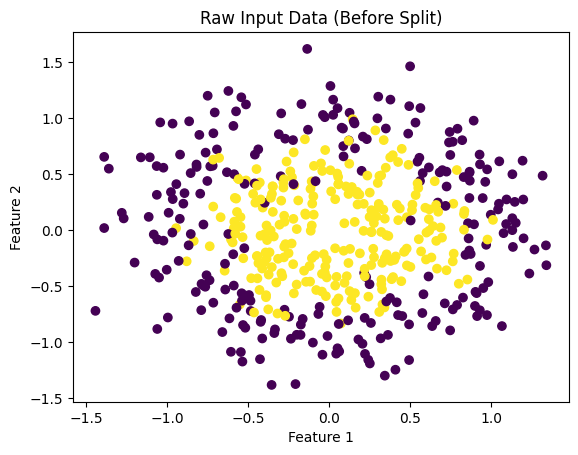

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score

from sklearn.datasets import make_circles

X, y = make_circles(n_samples=500, noise=0.2, factor=0.5, random_state=42)
# Visualize raw dataset
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Raw Input Data (Before Split)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [40]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [41]:
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("R2 score:", r2_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.88
R2 score: 0.5104039167686658

Confusion Matrix:
 [[41  2]
 [10 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.95      0.87        43
           1       0.96      0.82      0.89        57

    accuracy                           0.88       100
   macro avg       0.88      0.89      0.88       100
weighted avg       0.89      0.88      0.88       100



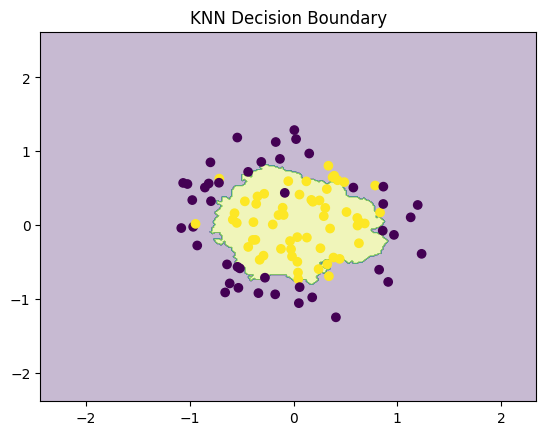

In [42]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = knn.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
plt.title("KNN Decision Boundary")
plt.show()